# 🧱 Neural-network building blocks — and how to pick them

In `music_generation_midi.ipynb` the model was this stack:

```python
nn.Embedding(...)          # turn chord numbers into vectors
nn.MultiheadAttention(...) # let chords look at each other
nn.Sequential(             # a small "feed-forward" block
    nn.Linear(...), nn.ReLU(), nn.Linear(...))
nn.LayerNorm(...)          # keep the numbers well-behaved
nn.Linear(...)             # produce the final scores
```

If that felt like alphabet soup — good, this notebook is for you. Here's the key idea:

> A neural network is **Lego**. There are only a handful of bricks. Each one does *one small,
> understandable thing to a bunch of numbers.* A "model" is just a sensible stack of them.

We'll pick up each brick, poke it with tiny inputs so you can **see** what it does, and then finish
with a **decision guide**: given your problem, which bricks do you actually need? Run the cells top
to bottom — every experiment is small enough to read.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from ipywidgets import interact, Dropdown

plt.rcParams["figure.figsize"] = (7, 3.5)
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__)

torch 2.12.1


## 1. `nn.Linear` — the workhorse

**What it does:** takes a vector of numbers and produces *another* vector, by mixing the inputs
with **learned weights** (plus a bias). That's it. Every "smart" layer is built out of these.

`nn.Linear(in_features, out_features)` holds:
- a **weight** matrix of shape `(out, in)` — one learned recipe per output number, and
- a **bias** vector of shape `(out,)`.

The output is literally `y = x @ W.T + b`. Nothing mysterious — it's a weighted sum.

**Mental model:** a Linear layer *resizes and remixes* a vector. Turn 3 numbers into 2, or 16 into
7. It's the layer that changes the *shape* of your data and learns which inputs matter.

In [3]:
lin = nn.Linear(in_features=3, out_features=2)
print("weight shape:", tuple(lin.weight.shape), " bias shape:", tuple(lin.bias.shape))

x = torch.tensor([1.0, 2.0, 3.0])
print("\ninput x        :", x.tolist())
print("Linear(x)      :", lin(x).detach().tolist())

# ...which is exactly this by hand:
manual = x @ lin.weight.T + lin.bias
print("x @ W.T + b    :", manual.detach().tolist(), " <- same thing")

weight shape: (2, 3)  bias shape: (2,)

input x        : [1.0, 2.0, 3.0]
Linear(x)      : [-0.8218859434127808, 0.0526045560836792]
x @ W.T + b    : [-0.8218859434127808, 0.0526045560836792]  <- same thing


## 2. Activation (`nn.ReLU`) — the "bend" that makes it powerful

Here's a surprise: if you stack two Linear layers with nothing in between, you get... a single
Linear layer. Math collapses `Linear(Linear(x))` back into one weighted sum. Stacking alone buys
you **nothing**.

The fix is an **activation function** — a simple non-linear bend placed *between* Linears. The most
common is **ReLU**: "keep positives, zero out negatives" (`max(0, x)`). That tiny kink is what lets
a network approximate curves, decision boundaries, and complicated patterns instead of just
straight lines.

**Rule of thumb:** put a ReLU (or similar) between Linear layers. Without it, depth is pointless.

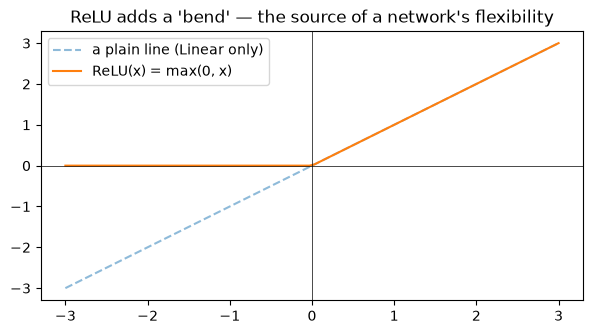

ReLU zeros out the negatives:
[0.0, 0.0, 0.0, 1.5, 4.0]


In [3]:
x = torch.linspace(-3, 3, 100)
fig, ax = plt.subplots()
ax.plot(x, x, "--", label="a plain line (Linear only)", alpha=0.5)
ax.plot(x, torch.relu(x), label="ReLU(x) = max(0, x)")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_title("ReLU adds a 'bend' — the source of a network's flexibility")
ax.legend(); plt.show()

print("ReLU zeros out the negatives:")
print(torch.relu(torch.tensor([-2.0, -0.5, 0.0, 1.5, 4.0])).tolist())

## 3. `nn.Sequential` — the container (just plumbing)

`nn.Sequential` isn't math at all — it's a **box that runs layers in order**. You hand it a list of
bricks and it pipes the output of each into the next. It exists purely to keep your code tidy.

A Linear → ReLU → Linear stack is so common it has a name: a **multi-layer perceptron (MLP)**, or
"feed-forward" block. That's exactly the `nn.Sequential(...)` you saw inside the chord model — a
little block that reshapes features.

**When you use it:** whenever you have a fixed chain of layers you always run back-to-back and want
to treat as one unit.

In [4]:
mlp = nn.Sequential(
    nn.Linear(3, 8),   # 3 numbers -> 8
    nn.ReLU(),         # bend
    nn.Linear(8, 2),   # 8 -> 2
)
print(mlp)
print("\nmlp(x) =", mlp(torch.tensor([1.0, 2.0, 3.0])).detach().tolist())
print("It just ran the three layers in order.")

Sequential(
  (0): Linear(in_features=3, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=2, bias=True)
)

mlp(x) = [0.025605380535125732, -0.3894197344779968]
It just ran the three layers in order.


## 4. `nn.Embedding` — turn IDs into vectors

Linear layers eat *numbers with meaning* (a temperature, a price). But what if your input is a
**category** — a word, a chord, a user ID? The integer `4` for "the 5th chord" isn't *quantity* 4;
it's just a name. Feeding it in raw would fool the network into thinking chord 4 is "twice" chord 2.

`nn.Embedding(num_embeddings, embedding_dim)` solves this. It's a **lookup table**: one learned
vector per category. You pass in IDs, it hands back their rows. Those vectors start random and, as
training runs, categories that behave alike drift close together — the network *learns the meaning*
of each ID.

**When you use it:** your input is **discrete tokens / categories** (words, chords, product IDs).
It's almost always the *first* layer for that kind of data.

In [5]:
emb = nn.Embedding(num_embeddings=7, embedding_dim=4)   # 7 chords -> 4-D vectors
print("The lookup table (7 rows, one per chord):")
print(emb.weight.detach().round(decimals=2))

ids = torch.tensor([0, 4, 4, 1])
print("\nLook up chords", ids.tolist(), "-> just grabs those rows:")
print(emb(ids).detach().round(decimals=2))

The lookup table (7 rows, one per chord):
tensor([[-0.5700, -0.5600,  0.5900,  1.5400],
        [ 0.5100, -0.5900, -0.5700,  0.9200],
        [-0.0700, -0.4900, -1.5000, -0.1900],
        [ 1.0400,  0.3600, -0.0000, -0.5300],
        [ 1.1700,  0.3900,  1.9400,  0.7900],
        [ 0.0300,  0.7100, -1.5400, -0.4100],
        [ 0.9700,  1.6200, -0.3700, -1.3000]])

Look up chords [0, 4, 4, 1] -> just grabs those rows:
tensor([[-0.5700, -0.5600,  0.5900,  1.5400],
        [ 1.1700,  0.3900,  1.9400,  0.7900],
        [ 1.1700,  0.3900,  1.9400,  0.7900],
        [ 0.5100, -0.5900, -0.5700,  0.9200]])


## 5. `nn.LayerNorm` — keep the numbers sane

As data flows through many layers, the numbers can drift huge or tiny, and training gets shaky.
**LayerNorm** is a stabilizer: for each example it rescales the vector to have roughly **mean 0 and
standard deviation 1**, then lets the model learn a gentle re-scale/shift on top.

Think of it as an *automatic volume control* between layers — it stops any one signal from blowing
out. You don't need it in small shallow nets, but in deep networks and transformers it's standard
and makes training much smoother.

**When you use it:** deeper models (especially anything with attention). If a small MLP trains fine
without it, you don't need it.

before -> mean 13.80, std 8.21
after  -> mean 0.00, std 1.00  (~0 and ~1)


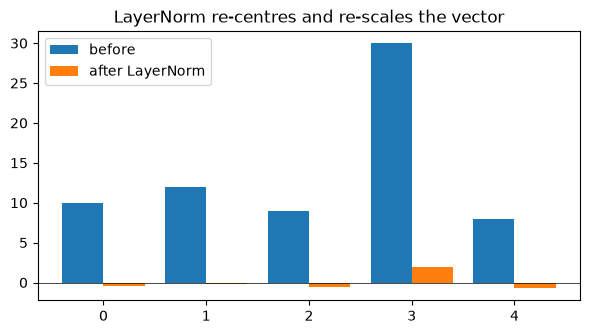

In [6]:
ln = nn.LayerNorm(5)
v = torch.tensor([10.0, 12.0, 9.0, 30.0, 8.0])   # uneven, one big spike
out = ln(v).detach()

print(f"before -> mean {v.mean():.2f}, std {v.std(unbiased=False):.2f}")
print(f"after  -> mean {out.mean():.2f}, std {out.std(unbiased=False):.2f}  (~0 and ~1)")

fig, ax = plt.subplots()
idx = np.arange(5)
ax.bar(idx - 0.2, v, 0.4, label="before")
ax.bar(idx + 0.2, out, 0.4, label="after LayerNorm")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("LayerNorm re-centres and re-scales the vector"); ax.legend(); plt.show()

## 6. `nn.MultiheadAttention` — let items look at each other

Everything so far treats one vector at a time. But a **sequence** — words in a sentence, chords in a
progression — is about *relationships*: what each item means depends on the others around it.

**Attention** is the brick for that. For every position it asks: *"which other positions should I pay
attention to?"*, builds a set of weights that sum to 1, and mixes the others' vectors together
accordingly. (Under the hood each item emits a **query**, a **key**, and a **value** — the query/key
match decides the weights, and the values get blended. You don't have to build that by hand;
`nn.MultiheadAttention` does it.)

It returns two things: the mixed vectors, **and** the attention weights themselves — which we can
plot to literally see who looked at whom.

**When you use it:** your data is a **sequence or a set** whose items relate to one another. For a
*predict-the-next-item* task you add a **causal mask** so a position can only look backward, never at
the future (that's the mask in the chord model).

input sequence shape : (1, 3, 4)
mixed output shape   : (1, 3, 4)  (same shape -> stackable)
attention weights (rows sum to 1):
tensor([[0.1100, 0.4900, 0.4100],
        [0.4200, 0.2600, 0.3200],
        [0.7000, 0.1600, 0.1500]])


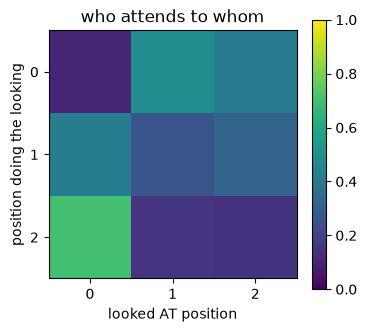

In [7]:
attn = nn.MultiheadAttention(embed_dim=4, num_heads=1, batch_first=True)
seq = torch.randn(1, 3, 4)                 # 1 batch, 3 positions, 4-D each
mixed, weights = attn(seq, seq, seq)       # self-attention: query=key=value=seq

print("input sequence shape :", tuple(seq.shape))
print("mixed output shape   :", tuple(mixed.shape), " (same shape -> stackable)")
print("attention weights (rows sum to 1):")
print(weights[0].detach().round(decimals=2))

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(weights[0].detach(), cmap="viridis", vmin=0, vmax=1)
ax.set_xlabel("looked AT position"); ax.set_ylabel("position doing the looking")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_title("who attends to whom"); fig.colorbar(im); plt.show()

## 7. The `x + layer(x)` trick — residual connections

One more pattern you saw: `h = norm(h + attended)`. Why add the input back to a layer's output?

This is a **residual (skip) connection**. Instead of forcing a layer to output the whole answer, we
let it output only a *small adjustment* that gets **added** to what came in. Two big wins:

1. If a layer has nothing useful to add, it can output ~0 and the input passes through untouched —
   so extra depth never *hurts*.
2. It gives gradients a clean "shortcut" back through the network, which makes deep models trainable.

It only works when the layer keeps the shape the same (input and output both `embed_dim`) — which is
exactly why attention and the feed-forward block are built to preserve shape.

In [8]:
layer = nn.Linear(4, 4)
h = torch.randn(1, 3, 4)

plain    = layer(h)          # layer replaces the signal
residual = h + layer(h)      # layer only *adjusts* the signal
print("input, plain, residual all share shape:", tuple(h.shape),
      tuple(plain.shape), tuple(residual.shape))
print("residual = input + adjustment, so the original always survives.")

input, plain, residual all share shape: (1, 3, 4) (1, 3, 4) (1, 3, 4)
residual = input + adjustment, so the original always survives.


## 8. Read the chord model with new eyes

Now the "alphabet soup" from the start reads as a sentence. Here is the same model, annotated:

```python
class ChordAttention(nn.Module):
    def __init__(self, ...):
        self.chord_embed = nn.Embedding(vocab_size, embed_dim)  # 1. IDs  -> vectors
        self.pos_embed   = nn.Embedding(seq_len,   embed_dim)   #    +position vectors
        self.attn  = nn.MultiheadAttention(embed_dim, n_heads)  # 6. chords look at each other
        self.ff    = nn.Sequential(                             # 3. feed-forward block
            nn.Linear(embed_dim, 4*embed_dim), nn.ReLU(),       #    2. bend
            nn.Linear(4*embed_dim, embed_dim))
        self.norm1 = nn.LayerNorm(embed_dim)                    # 5. stabilise
        self.norm2 = nn.LayerNorm(embed_dim)
        self.head  = nn.Linear(embed_dim, vocab_size)           # 1. -> one score per chord

    def forward(self, x):
        h = self.chord_embed(x) + self.pos_embed(positions)     # embed + position
        h = self.norm1(h + self.attn(h, h, h, mask)[0])         # 7. attention + residual + norm
        h = self.norm2(h + self.ff(h))                          # 7. feed-forward + residual + norm
        return self.head(h[:, -1, :])                           # last position -> next-chord scores
```

| Brick | Role here | The general job |
|-------|-----------|-----------------|
| `Embedding` | chord/position IDs → vectors | discrete input → vectors |
| `MultiheadAttention` | each chord reads the others | relate items in a sequence |
| `Sequential(Linear, ReLU, Linear)` | reshape each chord's features | a feed-forward transform |
| `LayerNorm` | keep activations tame | stabilise deep training |
| `+ ...` (residual) | let layers *adjust*, not replace | trainable depth |
| final `Linear` | 16-D vector → 7 chord scores | produce the output |

## 9. How to know which bricks *you* need

You don't memorise architectures — you **read your problem** and assemble bricks. Walk these
questions in order:

**A. What does your input look like?**
- Fixed list of meaningful numbers (age, price, sensor readings) → go straight to **`Linear` + `ReLU`** stacks (an MLP).
- Discrete categories / tokens (words, chords, IDs) → start with an **`Embedding`**.
- A sequence or set where items relate (sentence, melody, time series) → add **attention** (or an RNN/`nn.LSTM`). Predicting the *next* item? add a **causal mask**.
- A grid with local structure (images) → convolutions (`nn.Conv2d`) — a different brick, same spirit.

**B. What is the output?**
- Pick **one class** out of N → final **`Linear(→ N)`** + `CrossEntropyLoss`.
- Predict a **number** → final **`Linear(→ 1)`** + `MSELoss`.

**C. Housekeeping**
- Always put an **activation** (ReLU) *between* Linear layers.
- Going **deep** or using **attention**? add **`LayerNorm`** + **residual** connections.
- Use **`Sequential`** whenever you want to bundle a fixed chain into one tidy unit.

**Start small.** Get the simplest stack that could work training end-to-end first, then add bricks
(more layers, attention, norm) only when the numbers say you need them. The little helper below
turns these questions into a suggested stack — try a few combinations.

In [9]:
def recommend(input_type, output_type, items_relate, going_deep):
    steps = []
    if input_type == "categories / tokens":
        steps.append("nn.Embedding(num_ids, dim)        # IDs -> vectors")
    elif input_type == "sequence of tokens":
        steps.append("nn.Embedding(num_ids, dim) + position embedding")
    else:
        steps.append("(feed your numbers straight in as a vector)")

    if items_relate == "yes":
        steps.append("nn.MultiheadAttention(dim, heads) # items look at each other")
        steps.append("   + causal mask if predicting the NEXT item")

    steps.append("nn.Sequential(nn.Linear, nn.ReLU, nn.Linear)  # transform")

    if going_deep == "yes":
        steps.append("wrap blocks with: h = nn.LayerNorm(dim)(h + block(h))  # norm + residual")

    if output_type == "one class out of N":
        steps.append("nn.Linear(dim, N)                 # then CrossEntropyLoss")
    else:
        steps.append("nn.Linear(dim, 1)                 # then MSELoss")

    print("Suggested stack:\n")
    for i, s in enumerate(steps, 1):
        print(f"  {i}. {s}")

interact(
    recommend,
    input_type=Dropdown(options=["meaningful numbers", "categories / tokens",
                                 "sequence of tokens"], value="sequence of tokens"),
    output_type=Dropdown(options=["one class out of N", "a number"], value="one class out of N"),
    items_relate=Dropdown(options=["yes", "no"], value="yes", description="relate?"),
    going_deep=Dropdown(options=["yes", "no"], value="yes", description="deep?"),
);

interactive(children=(Dropdown(description='input_type', index=2, options=('meaningful numbers', 'categories /…

## 10. Cheat sheet

| Brick | One-line job | Reach for it when |
|-------|--------------|-------------------|
| `nn.Linear` | weighted sum; resize/remix a vector | always — it's the core transform & the output layer |
| activation (`nn.ReLU`) | add a non-linear bend | between Linear layers, every time |
| `nn.Sequential` | run layers in order (plumbing) | to bundle a fixed chain into one unit |
| `nn.Embedding` | lookup table: ID → learned vector | input is categories / tokens |
| `nn.LayerNorm` | rescale to mean 0 / std 1 | deep nets & attention (training stability) |
| `nn.MultiheadAttention` | items attend to each other | sequences/sets; mask for next-item prediction |
| residual `x + f(x)` | let a layer adjust, not replace | to make depth trainable |

The whole game: **look at your data → pick the bricks that match → start with the smallest stack that
could work → add more only when the loss curves ask for it.** Everything else is these same pieces,
stacked deeper.

Where to go next: open `music_generation_midi.ipynb` again and re-read the model — it should now feel
like plain sentences. Then try deleting the `LayerNorm`s or the attention block and watch what
happens to the loss.